# Imports

In [49]:
import warnings
import re
from datetime import datetime
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")

In [50]:
sns.set_theme(style="whitegrid", context = "talk")
PALLETTE = sns.color_palette("viridis", 10)
TIER_PALETTE = {1: "#2ecc71", 2: "#f1c40f", 3: "#e74c3c"}
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

CSV_PATH = ('/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/Scaler Clustering/scaler_clustering.csv')
CURRENT_YEAR = datetime.now().year

# Problem Statement

Scaler is an online tech-versity. The analytics team wants to profile the BEST companies and BEST job positions inside the learner database so that:
  - Marketing can target similar learners with similar profiles
  - Sales can quote relevant salary benchmarks to prospects
  - Product can surface role-specific learning paths
  - Leadership can track which companies pay Scaler alumni best

Approach:

- Step A  — Manual Clustering using Company / Job / Experience / CTC medians --> create Designation, Class and Tier flags (values 1,2,3)
- Step B  — Unsupervised Clustering (KMeans + Hierarchical) to discover natural learner segments without predefined rules

# Load & Basic EDA

In [51]:
df = pd.read_csv(CSV_PATH)
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [52]:
df = df.drop(columns = df.columns[0])

In [53]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)

Shape: (205843, 6)
Columns: ['company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position', 'ctc_updated_year']

Dtypes:
company_hash         object
email_hash           object
orgyear             float64
ctc                   int64
job_position         object
ctc_updated_year    float64
dtype: object


In [54]:
missing_count = df.isnull().sum()
missing_pct = (df.isna().mean()*100).round(2)
missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})

display(missing_table)

,Missing Count,Missing %
company_hash,44,0.02
email_hash,0,0.00
orgyear,86,0.04
ctc,0,0.00
job_position,52564,25.54
ctc_updated_year,0,0.00


In [55]:
duplicate_count = df.duplicated().sum()
duplicate_pct = round(df.duplicated().mean()*100, 2)
duplicate_table = pd.DataFrame({
    "Duplicate Count": [duplicate_count],
    "Duplicate %": [duplicate_pct]
})

display(duplicate_table)

,Duplicate Count,Duplicate %
0,34,0.02


In [56]:
print(f"Unique emails: {df['email_hash'].nunique():,} out of {len(df):,}")
print("Top 5 repeating emails:")
print(df['email_hash'].value_counts().head())

Unique emails: 153,443 out of 205,843
Top 5 repeating emails:
email_hash
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b    10
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c     9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee     9
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378     9
b4d5afa09bec8689017d8b29701b80d664ca37b83cb883376b2e95191320da66     8
Name: count, dtype: int64


Insights:

- Dataset has ~205k rows x 6 columns after dropping the unnamed index.
- orgyear and ctc_updated_year are floats because of NaNs - Will impute them and cast back to int
- Roughly 2-4% of email_hashes repeat. These are not duplicates - they are the same learner appearing multiple times because their CTC was updated.
- company_hash is free text (and anonymised) with heavy noise - regex cleaning is mandatory before grouping.

# Statistical Summary (Univariate Analysis)

In [57]:
print("Numerical Summary:")
display(df.describe().T.round(2))

Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
orgyear,205757.0,2014.88,63.57,0.0,2013.0,2016.0,2018.0,2.016500e+04
ctc,205843.0,2271685.04,11800914.44,2.0,530000.0,950000.0,1700000.0,1.000150e+09
ctc_updated_year,205843.0,2019.63,1.33,2015.0,2019.0,2020.0,2021.0,2.021000e+03


In [58]:
print("Job Position Value Counts (Top 10")
print(df['job_position'].value_counts().head(10))

Job Position Value Counts (Top 10
job_position
Backend Engineer          43554
FullStack Engineer        24717
Other                     18071
Frontend Engineer         10417
Engineering Leadership     6870
QA Engineer                6587
Data Scientist             5368
Android Engineer           5357
SDET                       4967
Devops Engineer            4612
Name: count, dtype: int64


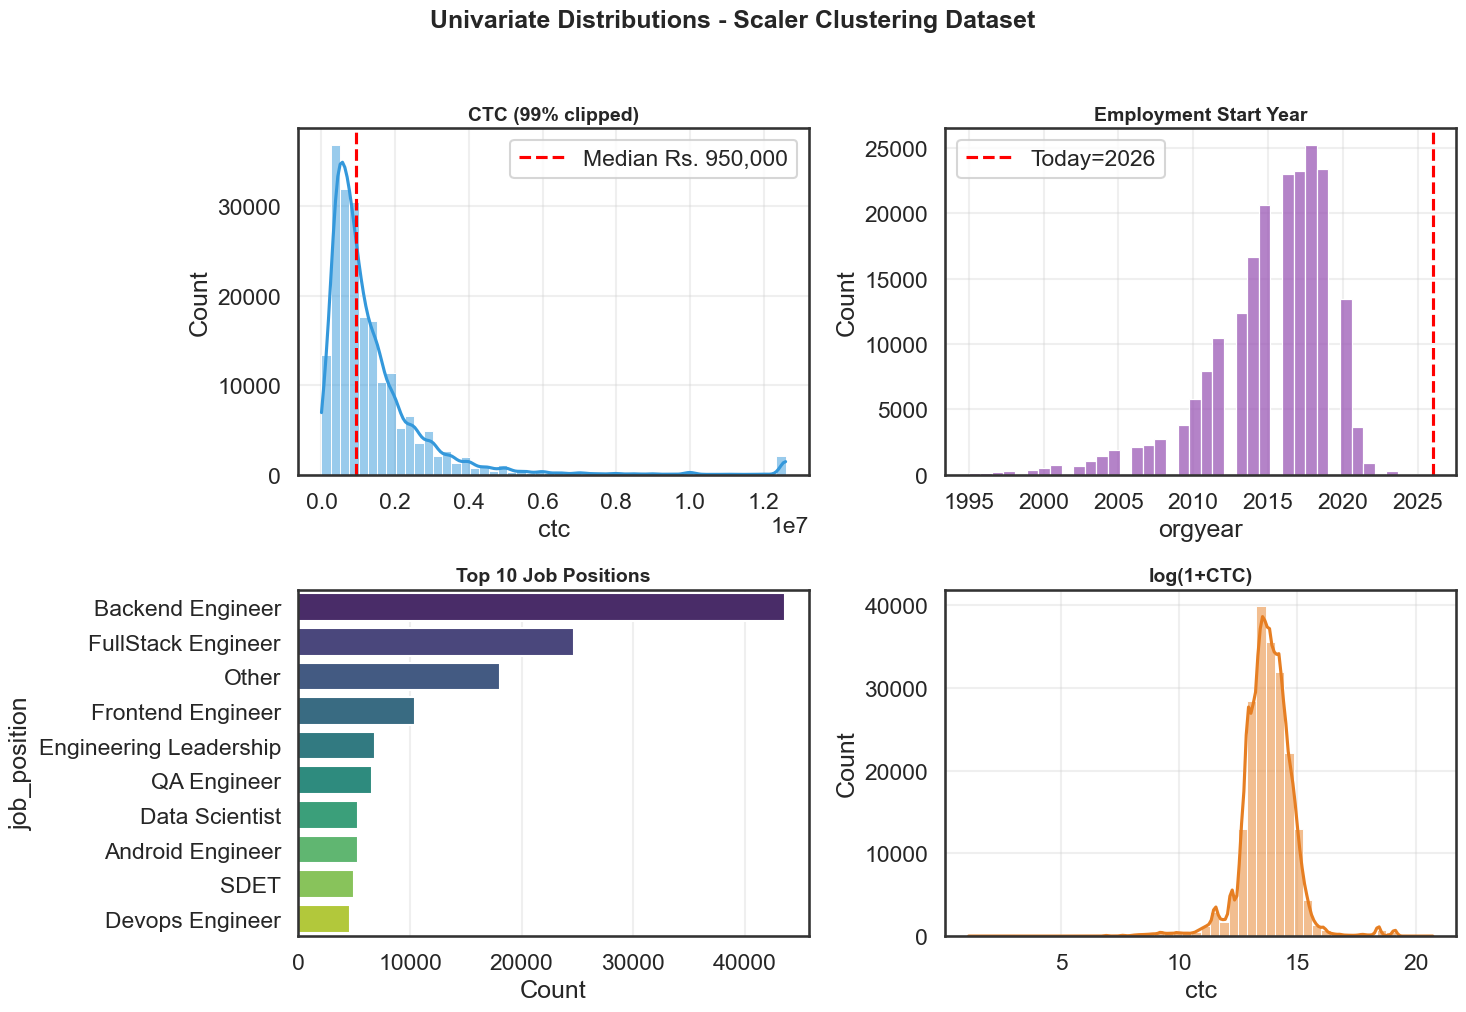

In [59]:
fig, axes = plt.subplots(2, 2, figsize = (15,10))
fig.suptitle("Univariate Distributions - Scaler Clustering Dataset", fontsize = 18, fontweight = 'bold', y = 1.02)

ctc_clip = df["ctc"].clip(upper=df['ctc'].quantile(0.99))
sns.histplot(ctc_clip, bins = 50, kde = True, color = "#3498db", ax = axes[0,0])
axes[0,0].set_title("CTC (99% clipped)")
axes[0,0].axvline(ctc_clip.median(), color = 'red', linestyle = "--", label = f"Median Rs. {ctc_clip.median():,.0f}")
axes[0,0].legend()

orgyear_clean = df["orgyear"].dropna()
orgyear_clean = orgyear_clean[(orgyear_clean >= 1995) & (orgyear_clean <= CURRENT_YEAR)]
sns.histplot(orgyear_clean, bins = 40, color = "#9b59b6", ax = axes[0,1])
axes[0,1].set_title("Employment Start Year")
axes[0,1].axvline(CURRENT_YEAR, color = 'red', linestyle = "--", label = f"Today={CURRENT_YEAR}")
axes[0,1].legend()

top_jobs = df["job_position"].value_counts().head(10)
sns.barplot(x=top_jobs.values, y = top_jobs.index, palette = 'viridis', ax = axes[1,0])
axes[1,0].set_title("Top 10 Job Positions")
axes[1,0].set_xlabel("Count")

sns.histplot(np.log1p(df["ctc"]), bins = 50, kde = True, color = "#e67e22", ax = axes[1,1])
axes[1,1].set_title("log(1+CTC)")
plt.tight_layout()
plt.show()

Insights:

- CTC is strongly right-skewed (a very few high salaries). Log-transform makes it roughly bell-shaped, which matters for KMeans distance metrics.
- orgyear has impossible values (some <1980 or > current year) - data errors that will be treated as missing.
- "Other" and "Backend Engineer" dominates job_position; "Data Scientist" and "ML Engineer" are smaller but high value segments worth highlighting.

# Bivariate Analysis

In [60]:
df_eda = df.copy()
df_eda["years_exp_tmp"] = CURRENT_YEAR - orgyear_clean
df_eda["ctc_clip"] = df_eda["ctc"].clip(upper=df_eda["ctc"].quantile(0.99))

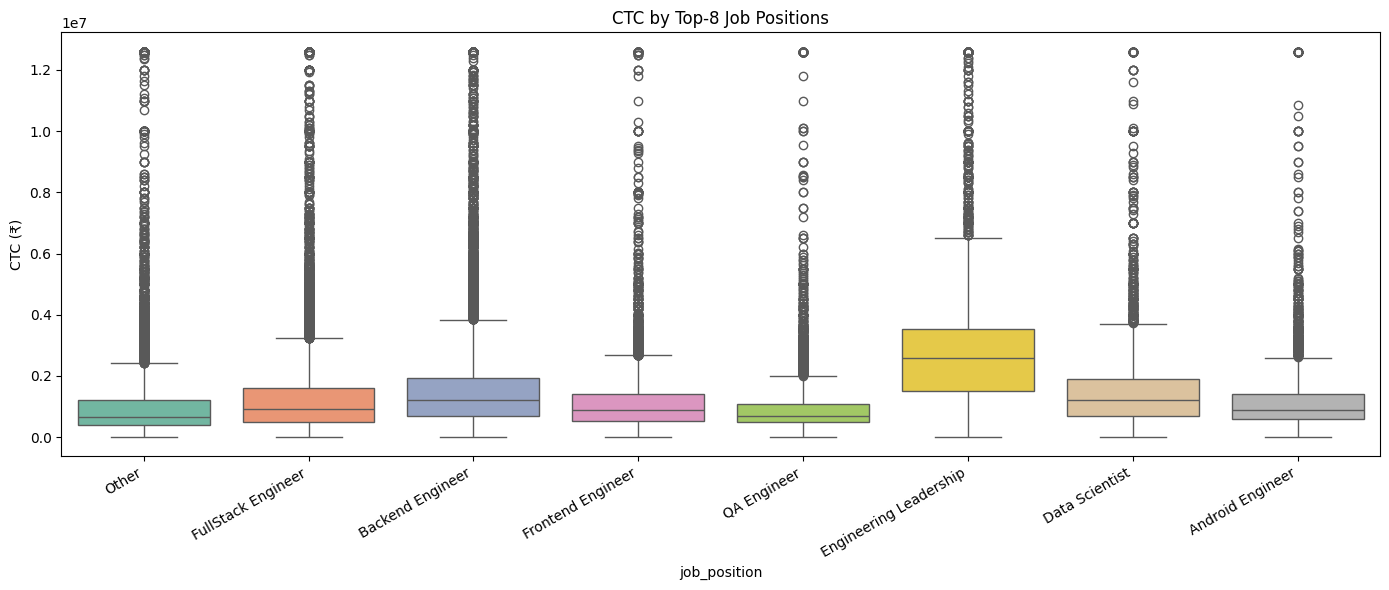

In [61]:
# ---- Boxplot: CTC by top-8 job positions ----
top8 = df_eda["job_position"].value_counts().head(8).index
plt.figure(figsize=(14,6))
sns.boxplot(data = df_eda[df_eda["job_position"].isin(top8)], x="job_position", y = "ctc_clip", palette = "Set2")
plt.xticks(rotation = 30, ha = "right")
plt.title("CTC by Top-8 Job Positions")
plt.ylabel("CTC (₹)")
plt.tight_layout()
plt.show()

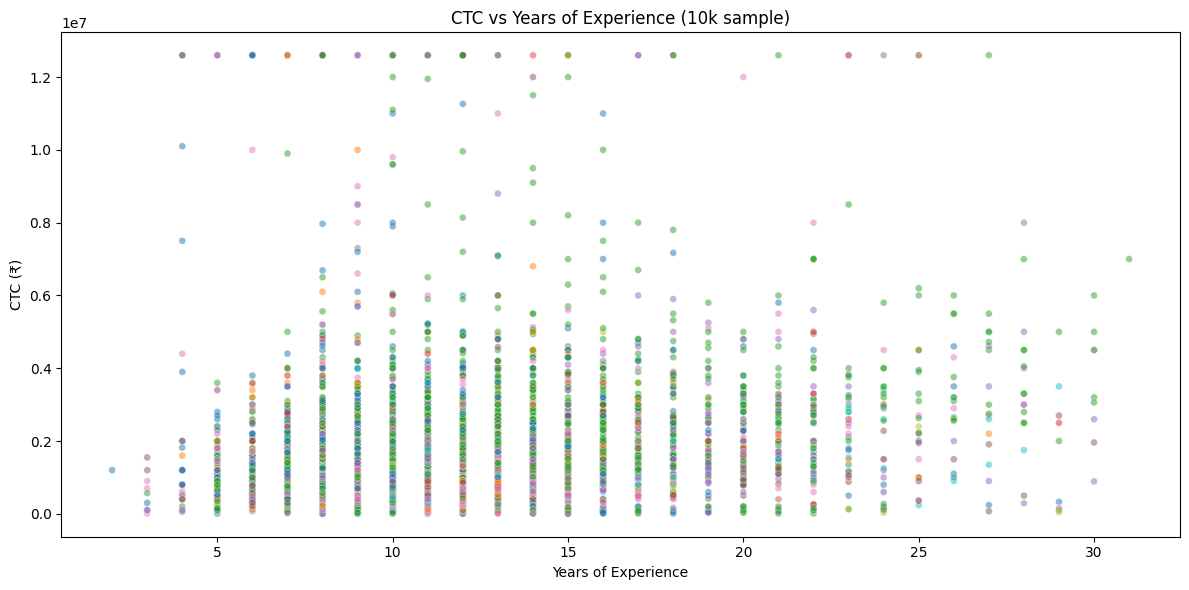

In [63]:
# ---- Scatter: experience vs CTC ----
plt.figure(figsize=(12,6))
sns.scatterplot(data = df_eda.sample(10000, random_state = 42),
                x = "years_exp_tmp", y = "ctc_clip",
                hue = "job_position", palette = "tab10",
                alpha = 0.5, s = 25, legend = False)
plt.title("CTC vs Years of Experience (10k sample)")
plt.xlabel("Years of Experience")
plt.ylabel("CTC (₹)")
plt.tight_layout()
plt.show()

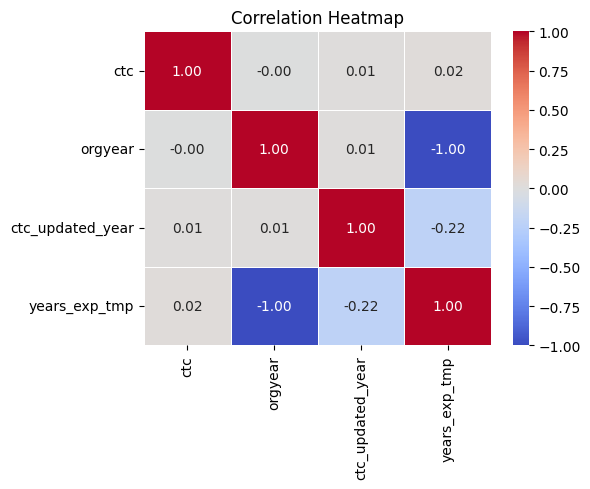

In [64]:
# Correlation heatmap
plt.figure(figsize = (6,5))
corr = df_eda[["ctc", "orgyear", "ctc_updated_year", "years_exp_tmp"]].corr()
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0, linewidths = 0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Insights

- Experience has only a mild positive coorelation with CTC.
- Backend, Data Scientist and ML Engineer roles have the widest CTC spread.
- ctc_updated_year is essentially the same information as orgyear for most learners (recent hires) so it adds little signal on its own

# Missing Value Treatment - Mean + KNN Imputation

In [ ]:
bad_year_mask = (df["orgyear"] < 1980 | df["orgyear"] > Current_YEAR)
print(f"orgyear values flagged as invalid: {bad_year_mask.sum():,}")
df.loc[bad_year_mask, "orgyear"] = np.nan